# MA515 - Fundamentals of Data Science
## Project: EM-GMM Speaker Recognition
### Team: For The Day Ones
- Shivam Bhagat (2022CSB1123)
- Prachi Chhabra (2022EEB1200)
- Saharsh Saxena (2022CBS1116)
- Pratibha Garg (2022EEB1204)
- Ishaan Sharma (2022EEB1173)
- Saaransh Sharma (2022CSB1114)

### Dataset Used: VoxCeleb1_Indian
This dataset contains audio samples from a number of Indian celebrities from different youtube videos in .wav format with speaker and video labels.

### Algorithm Used: EM on Gaussian Mixture Models (GMMs)
Train a GMM for each speaker using EM-algorithm and finally predict the speaker using log-likelihood.

## Imports

In [6]:
import numpy as np
import os
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

## Data Loading
Load speaker .wav paths and split into train/test sets.

In [7]:
def load_and_split_data(dataset_path, split_ratio=0.8):
    filepaths = {}
    for speaker_id in os.listdir(dataset_path):
        filepaths[speaker_id] = []
        speaker_path = os.path.join(dataset_path, speaker_id)
        if not os.path.isdir(speaker_path):
            continue
        for video_folder in os.listdir(speaker_path):
            video_path = os.path.join(speaker_path, video_folder)
            if not os.path.isdir(video_path):
                continue
            for file in os.listdir(video_path):
                if file.endswith('.wav'):
                    filepaths[speaker_id].append(os.path.join(video_path, file))
    train_files = {}
    test_files = {}
    for speaker, files in filepaths.items():
        if not files:
            continue
        np.random.shuffle(files)
        split_idx = int(len(files) * split_ratio)
        train_files[speaker] = files[:split_idx]
        test_files[speaker] = files[split_idx:]
    return train_files, test_files, list(filepaths.keys())

## Feature Extraction
Compute MFCC frames per file; aggregate per speaker.

In [8]:
def extract_features(file_list, n_mfcc):
    features = []
    for file in file_list:
        try:
            y, sr = librosa.load(file, sr=None)
            if len(y) == 0:
                continue
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
            features.extend(mfcc.T)
        except Exception as e:
            print(f"Error processing {file}: {e}")
    return np.array(features)

def prepare_features(train_files, test_files, speakers, n_mfcc):
    train_features = {}
    test_features = {}
    for speaker in speakers:
        if speaker in train_files:
            train_features[speaker] = extract_features(train_files[speaker], n_mfcc)
        if speaker in test_files:
            test_features[speaker] = {file: extract_features([file], n_mfcc) for file in test_files[speaker]}
    return train_features, test_features

## MFCC Visualization for a Single Audio Sample

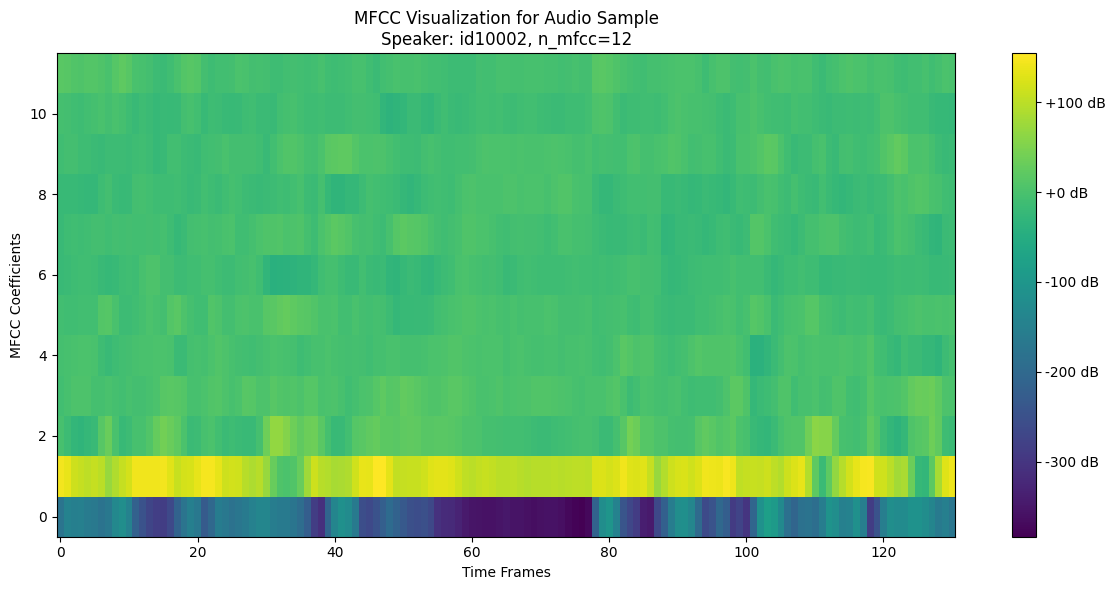

Audio file: dataset/vox1_indian/content/vox_indian/id10002\0_laIeN-Q44\00001.wav
MFCC shape: (12, 131)
Number of time frames: 131
Number of MFCC coefficients: 12


In [ ]:
dataset_path = 'dataset/vox1_indian/content/vox_indian/'
n_mfcc = 12

# Get a random audio file from the dataset
speaker_id = os.listdir(dataset_path)[0]
speaker_path = os.path.join(dataset_path, speaker_id)
video_folder = os.listdir(speaker_path)[0]
video_path = os.path.join(speaker_path, video_folder)
audio_files = [f for f in os.listdir(video_path) if f.endswith('.wav')]

if audio_files:
    sample_file = os.path.join(video_path, audio_files[0])

    # Load audio and extract MFCCs
    y, sr = librosa.load(sample_file, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # Create visualization
    plt.figure(figsize=(12, 6))
    plt.imshow(mfcc, aspect='auto', origin='lower', cmap='viridis')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'MFCC Visualization for Audio Sample\nSpeaker: {speaker_id}, n_mfcc={n_mfcc}')
    plt.xlabel('Time Frames')
    plt.ylabel('MFCC Coefficients')
    plt.tight_layout()
    plt.show()

    print(f"Audio file: {sample_file}")
    print(f"MFCC shape: {mfcc.shape}")
    print(f"Number of time frames: {mfcc.shape[1]}")
    print(f"Number of MFCC coefficients: {mfcc.shape[0]}")
else:
    print("No audio files found in the dataset.")


## GMM Model
EM-based Gaussian Mixture: fit updates parameters; score gives avg log-likelihood.

In [9]:
class GaussianMixtureModel:
    def __init__(self, n_components=2, n_iters=200, reg_covar=1e-6):
        self.n_components = n_components
        self.n_iters = n_iters
        self.reg_covar = reg_covar
        self.means = None
        self.covariances = None
        self.weights = None

    def fit(self, X):
        n_samples, n_features = X.shape
        if n_samples < self.n_components:
            print(f"Warning: n_samples={n_samples} < n_components={self.n_components}. Skipping fit.")
            self.means = np.zeros((self.n_components, n_features))
            self.covariances = np.array([np.eye(n_features)] * self.n_components)
            self.weights = np.ones(self.n_components) / self.n_components
            return
        self.means = X[np.random.choice(n_samples, self.n_components, False)]
        self.covariances = np.array([np.eye(n_features)] * self.n_components)
        self.weights = np.ones(self.n_components) / self.n_components
        for _ in range(self.n_iters):
            responsibilities = self._e_step(X)
            self._m_step(X, responsibilities)

    def score(self, X):
        log_likelihood = np.zeros(X.shape[0])
        for k in range(self.n_components):
            log_likelihood += self.weights[k] * self._gaussian(X, self.means[k], self.covariances[k])
        log_likelihood[log_likelihood == 0] = np.finfo(float).eps
        return np.log(log_likelihood).mean()

    def _e_step(self, X):
        n_samples = X.shape[0]
        responsibilities = np.zeros((n_samples, self.n_components))
        for k in range(self.n_components):
            responsibilities[:, k] = self.weights[k] * self._gaussian(X, self.means[k], self.covariances[k])
        row_sum = responsibilities.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1.0
        responsibilities /= row_sum
        return responsibilities

    def _m_step(self, X, responsibilities):
        n_samples, n_features = X.shape
        Nk = responsibilities.sum(axis=0)
        for k in range(self.n_components):
            Nk_k = Nk[k] + 1e-6
            self.means[k] = (responsibilities[:, k][:, np.newaxis] * X).sum(axis=0) / Nk_k
            diff = X - self.means[k]
            self.covariances[k] = (responsibilities[:, k][:, np.newaxis] * diff).T @ diff / Nk_k + np.eye(n_features) * self.reg_covar
            self.weights[k] = Nk[k] / n_samples

    def _gaussian(self, X, mean, covariance):
        n_features = X.shape[1]
        diff = X - mean
        try:
            inv_cov = np.linalg.inv(covariance)
            det_cov = np.linalg.det(covariance)
        except np.linalg.LinAlgError:
            covariance += np.eye(n_features) * self.reg_covar
            try:
                inv_cov = np.linalg.inv(covariance)
                det_cov = np.linalg.det(covariance)
            except np.linalg.LinAlgError:
                return np.full(X.shape[0], 1e-18)
        if det_cov <= 0:
            return np.full(X.shape[0], 1e-18)
        exponent = np.exp(-0.5 * np.sum(diff @ inv_cov * diff, axis=1))
        denominator = np.sqrt((2 * np.pi) ** n_features * det_cov)
        return exponent / (denominator + 1e-6)

## Training
Train one GMM per speaker; skip if no data.

In [10]:
def train_models(train_features, speakers, n_components, n_iters=200):
    gmm_models = {}
    for speaker in speakers:
        if speaker not in train_features or train_features[speaker].shape[0] == 0:
            continue
        gmm = GaussianMixtureModel(n_components=n_components, n_iters=n_iters)
        gmm.fit(train_features[speaker])
        gmm_models[speaker] = gmm
    return gmm_models

## Evaluation
Score each test clip across models; accuracy = correct / total.

In [11]:
def evaluate_models(test_features, gmm_models, speakers):
    correct = 0
    total_tests = 0
    for speaker, files in test_features.items():
        if speaker not in speakers:
            continue
        for file, features in files.items():
            if features.shape[0] == 0:
                continue
            total_tests += 1
            scores = {}
            for speaker_id, gmm in gmm_models.items():
                if speaker_id not in speakers:
                    continue
                score = gmm.score(features)
                scores[speaker_id] = score
            if not scores:
                continue
            predicted_speaker = max(scores, key=scores.get)
            if predicted_speaker == speaker:
                correct += 1
    if total_tests > 0:
        accuracy = correct / total_tests
        return accuracy
    else:
        return 0.0

## Experiment Routine
Pipeline: load data, extract features, train, evaluate, plot.

In [12]:
def run_experiment(n_mfcc, n_components):
    print(f"Running experiment with n_mfcc={n_mfcc}, n_components={n_components}")
    dataset_path = 'dataset/vox1_indian/content/vox_indian/'
    train_files, test_files, speakers = load_and_split_data(dataset_path)
    train_features, test_features = prepare_features(train_files, test_files, speakers, n_mfcc)
    gmm_models = train_models(train_features, speakers, n_components)
    accuracy = evaluate_models(test_features, gmm_models, speakers)
    print(f'Accuracy for n_mfcc={n_mfcc}, n_components={n_components}: {accuracy * 100:.2f}%')
    return accuracy

def plot_results(param_values, accuracies, param_name):
    plt.figure(figsize=(10, 5))
    plt.plot(param_values, accuracies, marker='o')
    plt.title(f'Accuracy vs. {param_name}')
    plt.xlabel(param_name)
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.show()

## Hyperparameter Sweeps
Vary MFCC count and mixture components; record accuracies.

Running experiment with n_mfcc=2, n_components=16
Accuracy for n_mfcc=2, n_components=16: 24.06%
Running experiment with n_mfcc=6, n_components=16
Accuracy for n_mfcc=6, n_components=16: 67.79%
Running experiment with n_mfcc=12, n_components=16
Accuracy for n_mfcc=12, n_components=16: 88.89%
Running experiment with n_mfcc=18, n_components=16
Accuracy for n_mfcc=18, n_components=16: 86.85%
Running experiment with n_mfcc=24, n_components=16
Accuracy for n_mfcc=24, n_components=16: 1.12%


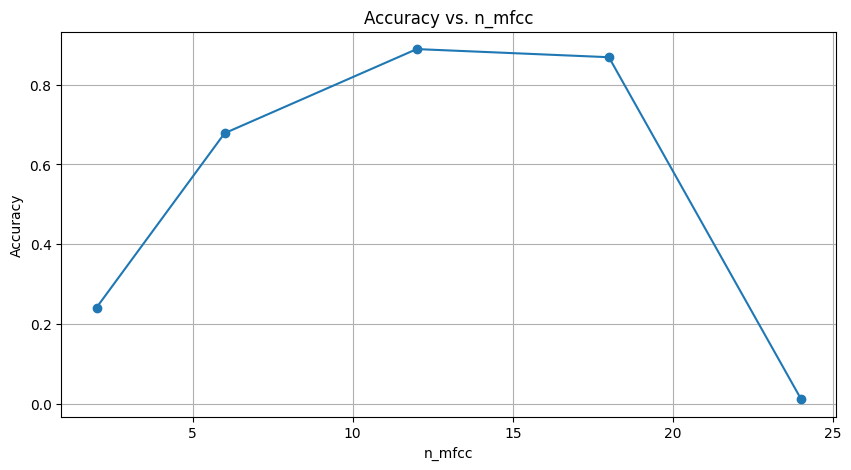

Running experiment with n_mfcc=8, n_components=2
Accuracy for n_mfcc=8, n_components=2: 54.43%
Running experiment with n_mfcc=8, n_components=6
Accuracy for n_mfcc=8, n_components=6: 72.88%
Running experiment with n_mfcc=8, n_components=12
Accuracy for n_mfcc=8, n_components=12: 77.17%
Running experiment with n_mfcc=8, n_components=18
Accuracy for n_mfcc=8, n_components=18: 82.47%
Running experiment with n_mfcc=8, n_components=24
Accuracy for n_mfcc=8, n_components=24: 78.08%


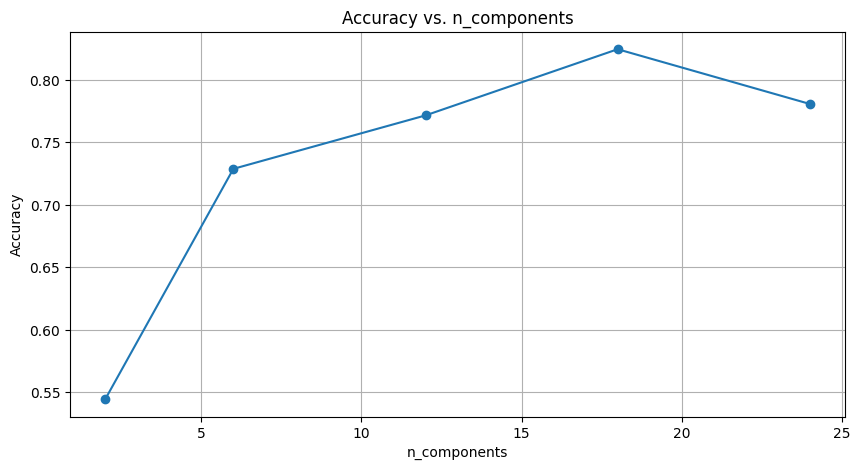

In [ ]:
n_mfcc_values = [2, 6, 12, 18, 24]
n_components_fixed = 16
mfcc_accuracies = []
for n_mfcc in n_mfcc_values:
    accuracy = run_experiment(n_mfcc=n_mfcc, n_components=n_components_fixed)
    mfcc_accuracies.append(accuracy)
plot_results(n_mfcc_values, mfcc_accuracies, 'n_mfcc')

n_mfcc_fixed = 8
n_components_values = [2, 6, 12, 18, 24]
components_accuracies = []
for n_components in n_components_values:
    accuracy = run_experiment(n_mfcc=n_mfcc_fixed, n_components=n_components)
    components_accuracies.append(accuracy)
plot_results(n_components_values, components_accuracies, 'n_components')

## Final Run
Execute best settings and report final accuracy.

In [ ]:
best_n_mfcc = 12
best_n_components = 16
final_accuracy = run_experiment(n_mfcc=best_n_mfcc, n_components=best_n_components)
print(f'Final accuracy with n_mfcc={best_n_mfcc} and n_components={best_n_components}: {final_accuracy * 100:.2f}%')

Running experiment with n_mfcc=12, n_components=16
Accuracy for n_mfcc=12, n_components=16: 88.48%
Final accuracy with n_mfcc=12 and n_components=16: 88.48%


### Final Results

**Optimal Hyperparameters**
- MFCC coefficients (`n_mfcc`): 12
- Mixture components (`n_components`): 16

**Final Accuracy**
- Achieved classification accuracy with these settings: **88.48%**

**Observation**
Higher MFCC count and moderate mixture size balanced detail and stability.

## Confusion Matrix
Generate confusion matrix to identify which speaker pairs are difficult to distinguish.

Training final model with n_mfcc=12, n_components=16

Confusion matrix saved to: confusion_matrix.png


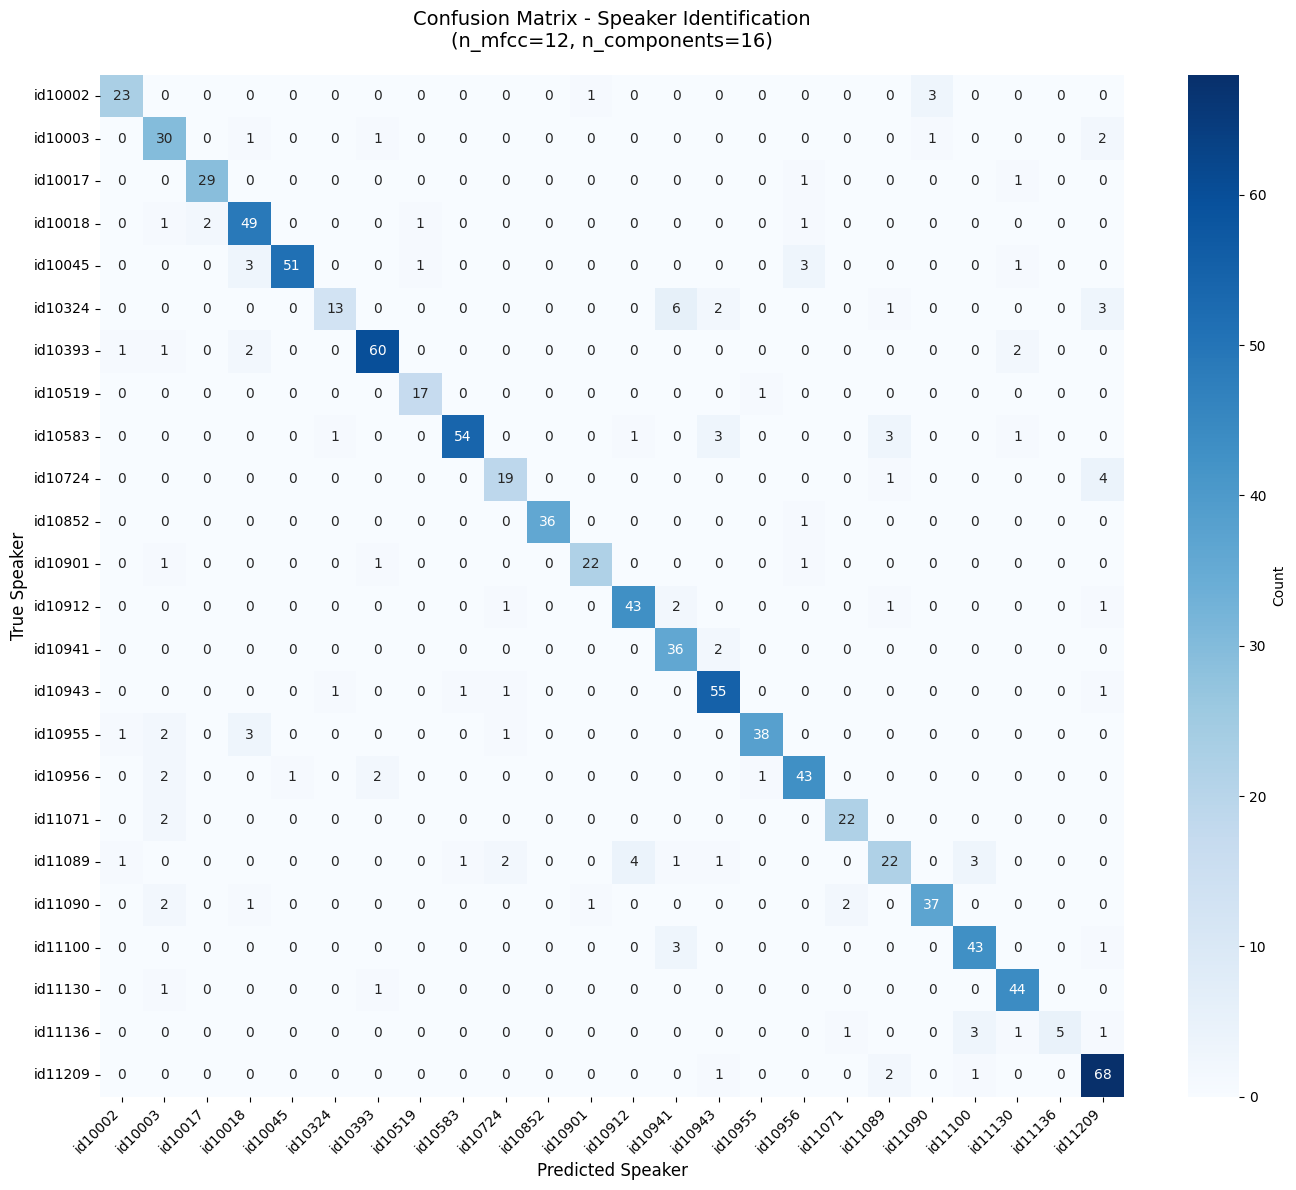


=== Per-Speaker Performance ===
id10002: 85.19% (23/27 correct)
id10003: 85.71% (30/35 correct)
id10017: 93.55% (29/31 correct)
id10018: 90.74% (49/54 correct)
id10045: 86.44% (51/59 correct)
id10324: 52.00% (13/25 correct)
id10393: 90.91% (60/66 correct)
id10519: 94.44% (17/18 correct)
id10583: 85.71% (54/63 correct)
id10724: 79.17% (19/24 correct)
id10852: 97.30% (36/37 correct)
id10901: 88.00% (22/25 correct)
id10912: 89.58% (43/48 correct)
id10941: 94.74% (36/38 correct)
id10943: 93.22% (55/59 correct)
id10955: 84.44% (38/45 correct)
id10956: 87.76% (43/49 correct)
id11071: 91.67% (22/24 correct)
id11089: 62.86% (22/35 correct)
id11090: 86.05% (37/43 correct)
id11100: 91.49% (43/47 correct)
id11130: 95.65% (44/46 correct)
id11136: 45.45% (5/11 correct)
id11209: 94.44% (68/72 correct)

=== Most Confused Speaker Pairs ===
id10324 misclassified as id10941: 6 times
id10724 misclassified as id11209: 4 times
id11089 misclassified as id10912: 4 times
id10002 misclassified as id11090: 3 t

In [13]:


def generate_confusion_matrix(n_mfcc, n_components):
    """
    Train model and generate confusion matrix for speaker identification.
    """
    print(f"Training final model with n_mfcc={n_mfcc}, n_components={n_components}")
    dataset_path = 'dataset/vox1_indian/content/vox_indian/'

    # Load and prepare data
    train_files, test_files, speakers = load_and_split_data(dataset_path)
    train_features, test_features = prepare_features(train_files, test_files, speakers, n_mfcc)

    # Train models
    gmm_models = train_models(train_features, speakers, n_components)

    # Collect predictions and true labels
    y_true = []
    y_pred = []

    for speaker, files in test_features.items():
        if speaker not in speakers:
            continue
        for file, features in files.items():
            if features.shape[0] == 0:
                continue

            # Calculate scores for all speakers
            scores = {}
            for speaker_id, gmm in gmm_models.items():
                if speaker_id not in speakers:
                    continue
                score = gmm.score(features)
                scores[speaker_id] = score

            if not scores:
                continue

            predicted_speaker = max(scores, key=scores.get)
            y_true.append(speaker)
            y_pred.append(predicted_speaker)

    return y_true, y_pred, speakers

# Generate confusion matrix with optimal hyperparameters
best_n_mfcc = 12
best_n_components = 16

y_true, y_pred, speakers = generate_confusion_matrix(best_n_mfcc, best_n_components)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=speakers)

# Visualize confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=speakers, yticklabels=speakers,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - Speaker Identification\n(n_mfcc={best_n_mfcc}, n_components={best_n_components})',
          fontsize=14, pad=20)
plt.xlabel('Predicted Speaker', fontsize=12)
plt.ylabel('True Speaker', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save as PNG
output_path = 'confusion_matrix.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\nConfusion matrix saved to: {output_path}")

plt.show()

# Calculate and display per-speaker accuracy
print("\n=== Per-Speaker Performance ===")
for i, speaker in enumerate(speakers):
    correct = cm[i, i]
    total = cm[i, :].sum()
    if total > 0:
        accuracy = (correct / total) * 100
        print(f"{speaker}: {accuracy:.2f}% ({correct}/{total} correct)")

# Identify most confused speaker pairs
print("\n=== Most Confused Speaker Pairs ===")
confusion_pairs = []
for i in range(len(speakers)):
    for j in range(len(speakers)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append((speakers[i], speakers[j], cm[i, j]))

confusion_pairs.sort(key=lambda x: x[2], reverse=True)
for true_speaker, pred_speaker, count in confusion_pairs[:10]:
    print(f"{true_speaker} misclassified as {pred_speaker}: {count} times")